In [22]:
import pandas as pd
from cv2 import threshold

data = {
    "Study_Hours": [1, 2, 2, 3, 4, 5, 6, 7, 8, 9],
    "Attendance": [50, 55, 60, 65, 68, 72, 78, 85, 90, 95],
    "Passed": [
        "No", "No", "No", "No", "No",
        "Yes", "Yes", "Yes", "Yes", "Yes"
    ]
}

df = pd.DataFrame(data)

print(df)

   Study_Hours  Attendance Passed
0            1          50     No
1            2          55     No
2            2          60     No
3            3          65     No
4            4          68     No
5            5          72    Yes
6            6          78    Yes
7            7          85    Yes
8            8          90    Yes
9            9          95    Yes


In [23]:
X = df[["Study_Hours", "Attendance"]]

y = df["Passed"]

In [24]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    random_state=42
)

model.fit(X, y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [25]:
new_student = pd.DataFrame({
    "Study_Hours": [6],
    "Attendance": [80]
})

prediction = model.predict(new_student)

print(prediction)

['Yes']


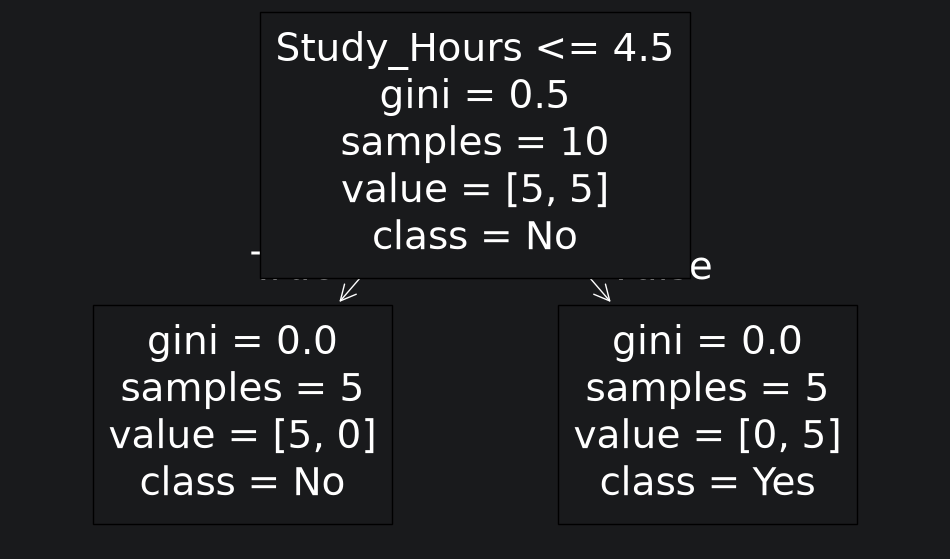

In [26]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,

)

plt.show()

In [13]:
def gini(y):
    probabilities = y.value_counts(normalize=True)
    return 1 - (probabilities ** 2).sum()

In [14]:
import pandas as pd

y = pd.Series(
    ["Yes", "Yes", "Yes", "No", "No", "No"]
)

print(gini(y))

0.5


0.0


In [27]:
y = pd.Series(
    ["Yes", "Yes", "Yes", "Yes", "Yes"]
)

print(gini(y))

0.0


DATASET
    Study_Hours  Attendance Passed
0             1          50     No
1             2          55     No
2             2          60     No
3             3          65     No
4             4          68     No
5             5          72    Yes
6             6          78    Yes
7             7          82    Yes
8             8          86    Yes
9             9          90    Yes
10           10          94    Yes
11           11          96    Yes

Predictions:
['Yes' 'Yes' 'No']

Actual:
['Yes' 'Yes' 'No']

Accuracy: 100.00%

Confusion Matrix:
[[1 0]
 [0 2]]

Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00         1
         Yes       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3


New Student Prediction:
Yes

Prediction Probabilities:
No: 0.00%
Yes: 1

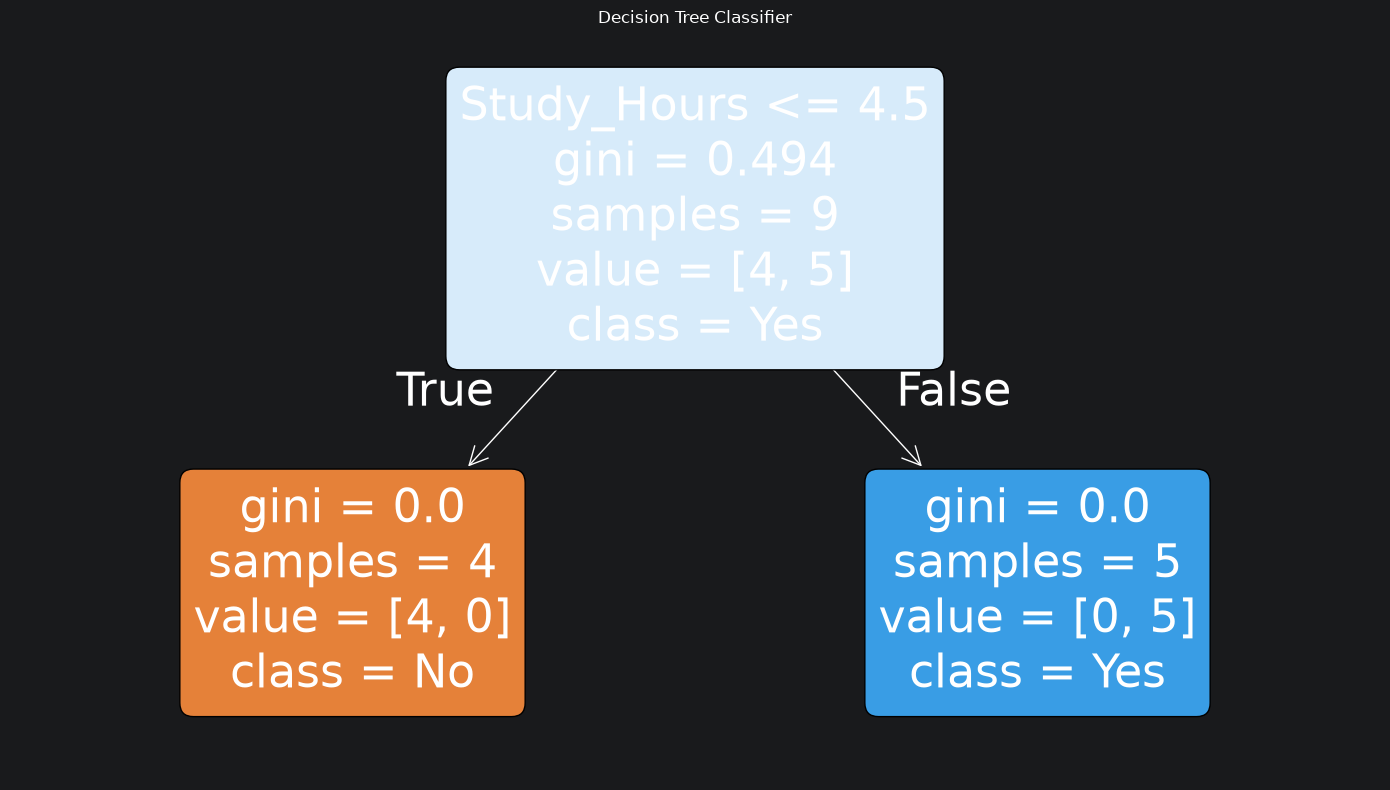

In [28]:
# ============================================
# DECISION TREE CLASSIFICATION
# MODERN SCIKIT-LEARN
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# ============================================
# 1. CREATE OUR OWN DATASET
# ============================================

data = {
    "Study_Hours": [1, 2, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
    "Attendance": [50, 55, 60, 65, 68, 72, 78, 82, 86, 90, 94, 96],
    "Passed": [
        "No", "No", "No", "No",
        "No", "Yes", "Yes", "Yes",
        "Yes", "Yes", "Yes", "Yes"
    ]
}

df = pd.DataFrame(data)

print("DATASET")
print(df)


# ============================================
# 2. FEATURES AND TARGET
# ============================================

X = df[["Study_Hours", "Attendance"]]
y = df["Passed"]


# ============================================
# 3. TRAIN / TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)


# ============================================
# 4. CREATE DECISION TREE
# ============================================

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)


# ============================================
# 5. TRAIN
# ============================================

model.fit(X_train, y_train)


# ============================================
# 6. PREDICTION
# ============================================

y_pred = model.predict(X_test)

print("\nPredictions:")
print(y_pred)

print("\nActual:")
print(y_test.to_numpy())


# ============================================
# 7. ACCURACY
# ============================================

accuracy = accuracy_score(y_test, y_pred)

print(f"\nAccuracy: {accuracy:.2%}")


# ============================================
# 8. CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

print("\nConfusion Matrix:")
print(cm)


# ============================================
# 9. CLASSIFICATION REPORT
# ============================================

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


# ============================================
# 10. PREDICT A NEW STUDENT
# ============================================

new_student = pd.DataFrame({
    "Study_Hours": [6],
    "Attendance": [80]
})

prediction = model.predict(new_student)

print("\nNew Student Prediction:")
print(prediction[0])


# ============================================
# 11. PREDICT PROBABILITIES
# ============================================

probabilities = model.predict_proba(new_student)

print("\nPrediction Probabilities:")

for class_name, probability in zip(
    model.classes_,
    probabilities[0]
):
    print(f"{class_name}: {probability:.2%}")


# ============================================
# 12. FEATURE IMPORTANCE
# ============================================

print("\nFeature Importance:")

for feature, importance in zip(
    X.columns,
    model.feature_importances_
):
    print(f"{feature}: {importance:.4f}")


# ============================================
# 13. TREE INFORMATION
# ============================================

print("\nTree Depth:")
print(model.get_depth())

print("\nNumber of Leaves:")
print(model.get_n_leaves())


# ============================================
# 14. PRINT TREE RULES AS TEXT
# ============================================

print("\nDecision Tree Rules:")

rules = export_text(
    model,
    feature_names=list(X.columns)
)

print(rules)


# ============================================
# 15. VISUALIZE THE TREE
# ============================================

plt.figure(figsize=(14, 8))

plot_tree(
    model,
    feature_names=list(X.columns),
    class_names=list(model.classes_),
    filled=True,
    rounded=True
)

plt.title("Decision Tree Classifier")
plt.tight_layout()
plt.show()

In [57]:
import pandas as pd

# Our dataset
data = {
    "Study_Hours": [1, 2, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
    "Passed": [
        "No", "No", "No", "No", "No",
        "Yes", "Yes", "Yes", "Yes", "Yes", "Yes", "Yes"
    ]
}
df =pd.DataFrame(data)
df

,Study_Hours,Passed
0,1,No
1,2,No
2,2,No
3,3,No
4,4,No
5,5,Yes
6,6,Yes
7,7,Yes
8,8,Yes
9,9,Yes


In [58]:
import pandas as pd

# Our dataset
data = {
    "Study_Hours": [1, 2, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
    "Passed": [
        "No", "No", "No", "No", "No",
        "Yes", "Yes", "Yes", "Yes", "Yes", "Yes", "Yes"
    ]
}

df = pd.DataFrame(data)


# --------------------------------------------
# Gini impurity function
# --------------------------------------------

def gini(y):
    probabilities = y.value_counts(normalize=True)
    return 1 - (probabilities ** 2).sum()


# --------------------------------------------
# Calculate Gini for a particular split
# --------------------------------------------

def split_gini(df, threshold):

    left = df[df["Study_Hours"] <= threshold]
    right = df[df["Study_Hours"] > threshold]

    # Gini of each child
    left_gini = gini(left["Passed"])
    right_gini = gini(right["Passed"])

    # Number of samples
    left_size = len(left)
    right_size = len(right)
    total = len(df)

    # Weighted Gini
    weighted_gini = (
        (left_size / total) * left_gini
        + (right_size / total) * right_gini
    )

    return weighted_gini


# --------------------------------------------
# Try different thresholds
# --------------------------------------------

thresholds = [1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5]

results = []

for threshold in thresholds:

    score = split_gini(df, threshold)

    results.append({
        "Threshold": threshold,
        "Gini": score
    })


# --------------------------------------------
# Show results
# --------------------------------------------

results_df = pd.DataFrame(results)

print(results_df)


# --------------------------------------------
# Find the best split
# --------------------------------------------

best_split = results_df.loc[
    results_df["Gini"].idxmin()
]

print("\nBest Split:")
print(best_split)

   Threshold      Gini
0        1.5  0.424242
1        2.5  0.259259
2        3.5  0.145833
3        4.5  0.000000
4        5.5  0.138889
5        6.5  0.238095
6        7.5  0.312500
7        8.5  0.370370
8        9.5  0.416667
9       10.5  0.454545

Best Split:
Threshold    4.5
Gini         0.0
Name: 3, dtype: float64


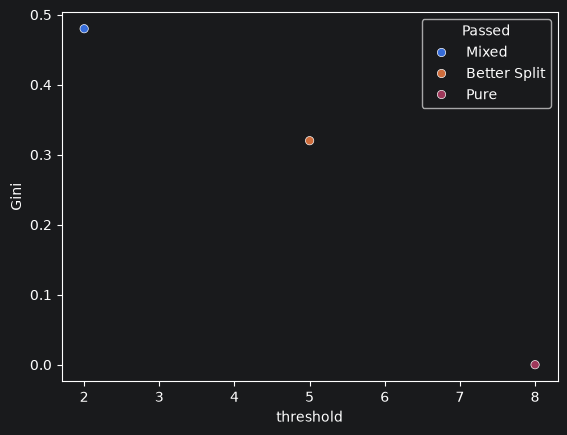

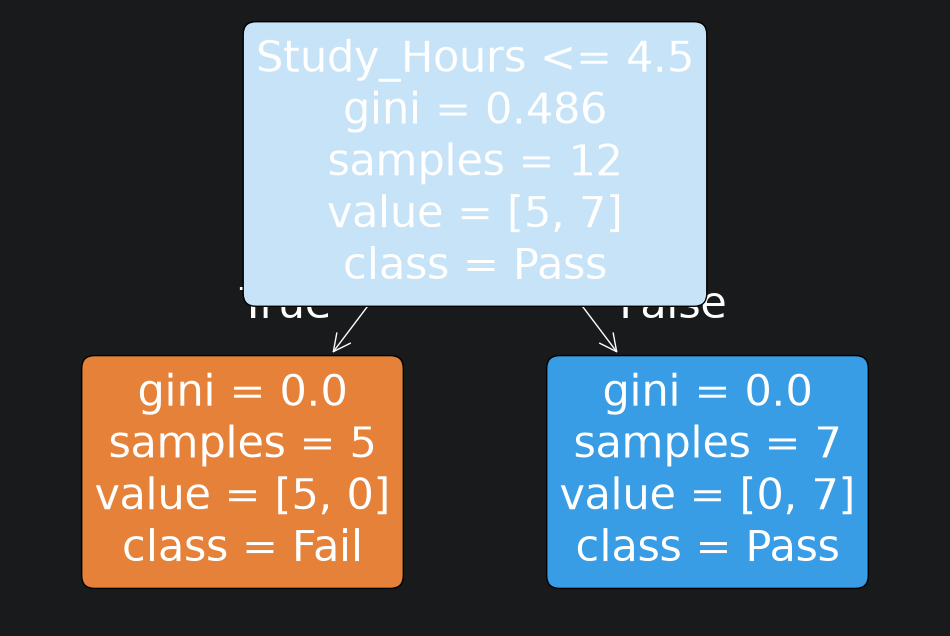

In [67]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Train the model
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)
model.fit(df[["Study_Hours"]], df["Passed"])

# Example results_df (you must compute these values yourself)
results_df = pd.DataFrame({
    "threshold": [2, 5, 8],
    "Gini": [0.48, 0.32, 0.0],
    "Passed": ["Mixed", "Better Split", "Pure"]
})

# Scatter plot
sns.scatterplot(
    data=results_df,
    x="threshold",
    y="Gini",
    hue="Passed"
)
plt.show()

# Plot the decision tree itself
plt.figure(figsize=(12, 8))
plot_tree(
    model,
    feature_names=["Study_Hours"],
    class_names=["Fail", "Pass"],  # adjust to match your df["Passed"]
    filled=True,
    rounded=True
)
plt.show()
